In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [15]:
data = pd.read_csv(r"C:\Users\kkrit\OneDrive\Documents\ML\archive (22)\ml-latest-small\ratings.csv")
data.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [16]:
user_item_matrix = data.pivot(index='userId', columns='movieId', values='rating').fillna(0)
matrix = user_item_matrix.values / 5.0

In [17]:
user_mean = np.mean(matrix, axis=1).reshape(-1,1)
matrix_centered = matrix - user_mean

In [ ]:
U, sigma, Vt = np.linalg.svd(matrix_centered, full_matrices=False)
k = 20  
sigma_k = np.diag(sigma[:k])
U_k = U[:, :k]
Vt_k = Vt[:k, :]

In [19]:
reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k) + user_mean
predicted = pd.DataFrame(reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)

In [20]:
mask = matrix > 0
actual = matrix[mask]
pred = reconstructed[mask]

rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.4724068823578077
MAE: 0.3957916413773053


In [21]:
user_id = user_item_matrix.index[0]  # first user
user_ratings = predicted.loc[user_id]
top_movies = user_ratings.sort_values(ascending=False).head(10)
top_movies

movieId
1196    0.996932
260     0.917450
1210    0.861684
2571    0.816926
2028    0.795997
589     0.785088
1197    0.762160
1198    0.750513
1240    0.744603
2858    0.741869
Name: 1, dtype: float64

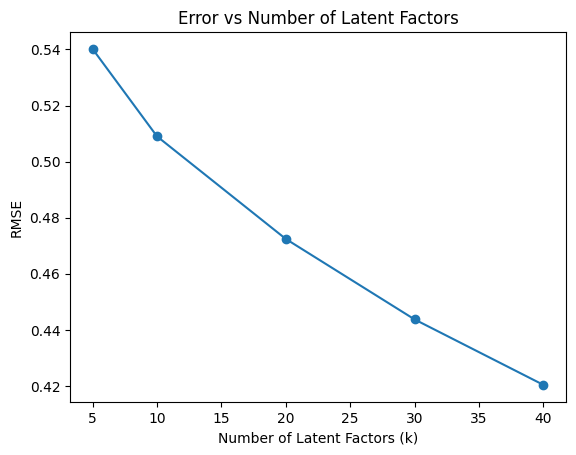

In [22]:
errors = []
k_values = [5, 10, 20, 30, 40]

for k in k_values:
    sigma_k = np.diag(sigma[:k])
    U_k = U[:, :k]
    Vt_k = Vt[:k, :]
    recon = np.dot(np.dot(U_k, sigma_k), Vt_k) + user_mean
    pred_k = recon[mask]
    errors.append(np.sqrt(mean_squared_error(actual, pred_k)))

plt.figure()
plt.plot(k_values, errors, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Number of Latent Factors")
plt.show()

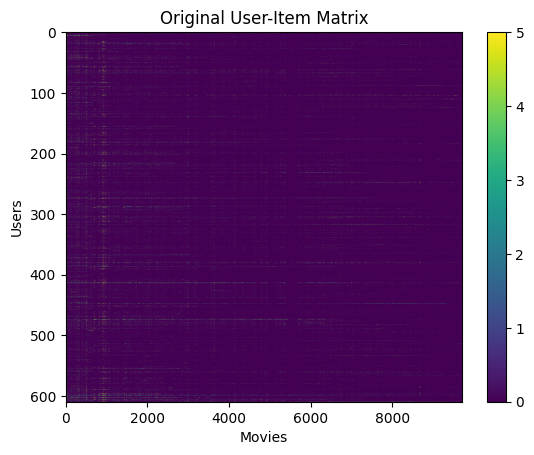

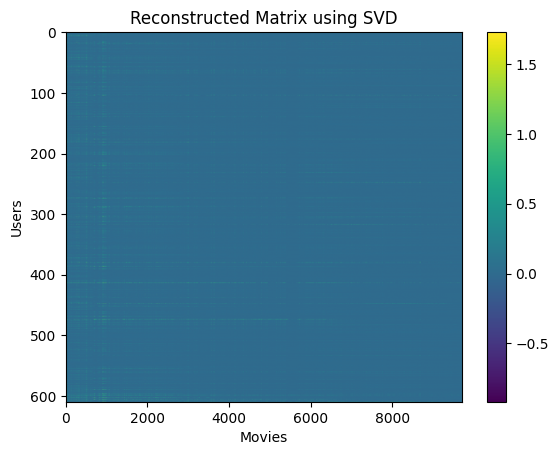

In [23]:
plt.figure()
plt.imshow(user_item_matrix.values, aspect='auto')
plt.colorbar()
plt.title("Original User-Item Matrix")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

plt.figure()
plt.imshow(reconstructed, aspect='auto')
plt.colorbar()
plt.title("Reconstructed Matrix using SVD")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

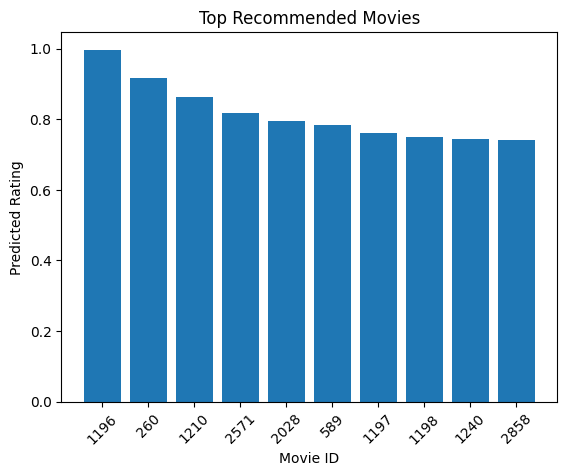

In [24]:
plt.figure()
plt.bar(range(len(top_movies)), top_movies.values)
plt.xticks(range(len(top_movies)), top_movies.index, rotation=45)
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.title("Top Recommended Movies")
plt.show()

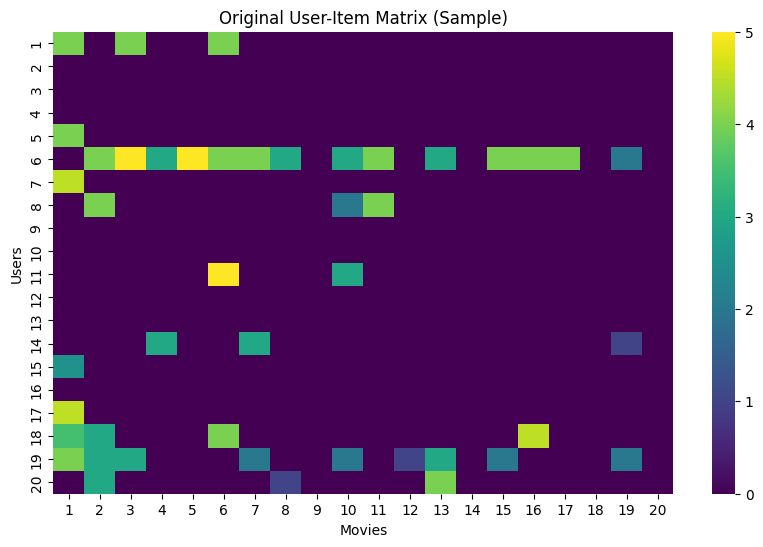

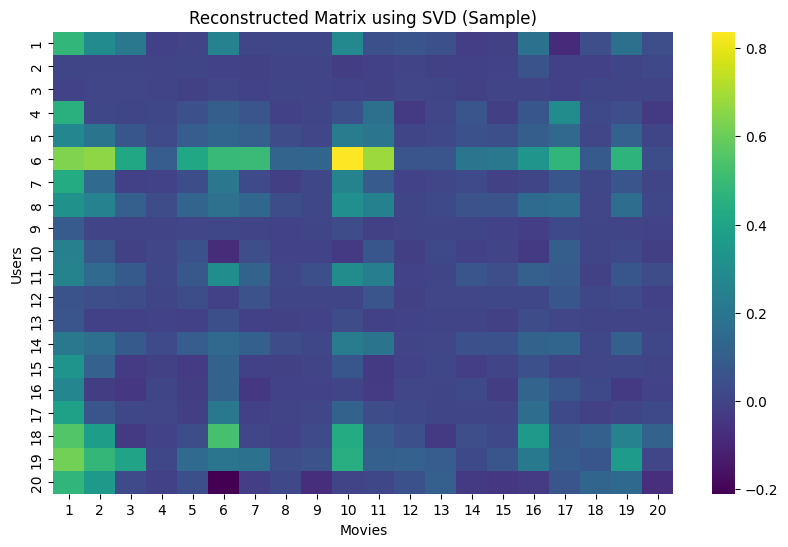

In [25]:
import seaborn as sns

sample_users = user_item_matrix.iloc[:20, :20]
sample_predicted = predicted.iloc[:20, :20]

plt.figure(figsize=(10,6))
sns.heatmap(sample_users, cmap='viridis')
plt.title("Original User-Item Matrix (Sample)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(sample_predicted, cmap='viridis')
plt.title("Reconstructed Matrix using SVD (Sample)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()